# Preproccessing and splitting

In [1]:
import json
import re
import unicodedata
from pathlib import Path
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Učitavanje chunkova

In [3]:
PROJECT_ROOT = Path.cwd()

CHUNKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "chunks.jsonl"
)


In [4]:
def load_jsonl(path: Path) -> list[dict]:
    records = []

    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()

            if not line:
                continue

            try:
                record = json.loads(line)
                records.append(record)

            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Neispravan JSON u redu {line_number}."
                ) from error

    return records

In [5]:
chunks = load_jsonl(CHUNKS_PATH)
print(f"Učitano je {len(chunks)} chunkova.")

Učitano je 356 chunkova.


In [6]:
# Sređivanje teksta
# Normalizacija unicode znakova
# Spajanje prelomljenih reči
# Uklanjanje neispravnih znakova,visestrukih redova i razmaka sa čuvanjem pasusa

In [7]:
def preprocess_text(text: str, lexical: bool = False) -> str:
    if not isinstance(text, str):
        return ""

    # Normalizacija Unicode znakova
    text = unicodedata.normalize("NFKC", text)

    # Ako su \n ostali kao bukvalni karakteri "\\" + "n"
    text = text.replace("\\r\\n", "\n")
    text = text.replace("\\n", "\n")
    text = text.replace("\\r", "\n")

    # Standardni prelomi redova
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # Uklanjanje dekorativnih simbola
    text = re.sub(r"[▶►▪■●◆◇◦•]", " ", text)

    # Uklanjanje nevidljivih znakova
    text = re.sub(
        r"[\u200b\u200c\u200d\u2060\ufeff]",
        "",
        text
    )

    # ---------------------------------------------------
    # SPAJANJE RECI PRELOMLJENIH NA KRAJU REDA
    #
    # informacio-
    # ni  -> informacioni
    # ---------------------------------------------------
    text = re.sub(
        r"(?<=\w)\s*-\s*\n\s*(?=\w)",
        "",
        text
    )

    # Znak zamene
    text = text.replace("�", "")

    # Normalizacija crtica
    text = re.sub(r"[‐-‒–—]", "-", text)

    # Normalizacija navodnika
    text = (
        text
        .replace("“", '"')
        .replace("”", '"')
        .replace("„", '"')
        .replace("’", "'")
        .replace("‘", "'")
    )

    # Preostale prelome redova pretvori u razmake
    text = re.sub(r"\s*\n+\s*", " ", text)

    # Spajanje visestrukih razmaka
    text = re.sub(r"[ \t]+", " ", text)

    if lexical:
        text = text.lower()

        # Interpunkciju pretvori u razmake
        text = re.sub(
            r"[^\w\s\-]",
            " ",
            text,
            flags=re.UNICODE
        )

        text = re.sub(r"\s+", " ", text)

    return text.strip()

In [8]:
processed_chunks = []

for chunk in chunks:
    processed_chunk = chunk.copy()

    # Prirodno ociscen tekst za dense 
    processed_chunk["processed_text"] = preprocess_text(
        chunk.get("text", ""),
        lexical=False
    )

    # Normalizovaniji tekst za TF-IDF / BM25
    processed_chunk["lexical_text"] = preprocess_text(
        chunk.get("text", ""),
        lexical=True
    )

    processed_chunks.append(processed_chunk)

In [9]:
print(f"Broj originalnih chunkova: {len(chunks)}")
print(f"Broj obrađenih chunkova: {len(processed_chunks)}")

Broj originalnih chunkova: 356
Broj obrađenih chunkova: 356


In [10]:
example_chunk = processed_chunks[0]

print("PRE SREĐIVANJA:\n")
print(example_chunk["text"][:700])

print("\nDENSE VERZIJA:\n")
print(example_chunk["processed_text"][:700])

print("\nLEXICAL VERZIJA (TF-IDF / BM25):\n")
print(example_chunk["lexical_text"][:700])

PRE SREĐIVANJA:

Pregled
1.1 Upravljanje kvalitetom softvera . . 4
-Koji procesi su važni za kvalitet softvera? -Koji su standardi kvaliteta softvera najbitnĳi i šta oni definišu?
1.2 Standardi . . . . . 4
1.3 Atributi kvaliteta softvera . . . . . . 5
-Kojim se atributima opisuje kvalitet softvera? -Koji atributi kvaliteta softvera su važni za bankarske aplikacĳe, koji za autonomnu vožnju, koji za kalkulator, koji za onlajn prodaju karata, a koji za sisteme za razmenu poruka?
Tokom poslednjih godina, IT industrĳa se brzo razvija i predstavlja jednu od najdinamičnĳih industrĳa u svetu. Softver se razvĳa za veoma raznovrsne uređaje i svrhe. Ove namene obuhvataju oblasti poput interneta stvari, virtuelne i proš

DENSE VERZIJA:

Pregled 1.1 Upravljanje kvalitetom softvera . . 4 -Koji procesi su važni za kvalitet softvera? -Koji su standardi kvaliteta softvera najbitniji i šta oni definišu? 1.2 Standardi . . . . . 4 1.3 Atributi kvaliteta softvera . . . . . . 5 -Kojim se atributima opisuje 

In [11]:
empty_chunks = [
    chunk["chunk_id"]
    for chunk in processed_chunks
    if not chunk["processed_text"] or not chunk["lexical_text"]
]

print(f"Broj praznih chunkova: {len(empty_chunks)}")

if empty_chunks:
    print("Prazni chunkovi:", empty_chunks)

Broj praznih chunkova: 0


In [12]:
# Učitavanje pitanja

In [13]:
QA_PATH = (
    PROJECT_ROOT
    / "data"
    / "questions"
    / "questions_answers.json"
)

with QA_PATH.open("r", encoding="utf-8") as file:
    qa_examples = json.load(file)

print(f"Učitano pitanja: {len(qa_examples)}")

Učitano pitanja: 143


In [14]:
processed_qa = []

for example in qa_examples:
    processed_example = example.copy()

    # Dense verzija pitanja
    processed_example["processed_question"] = preprocess_text(
        example.get("question", ""),
        lexical=False
    )

    # Leksikalna verzija pitanja za TF-IDF / BM25
    processed_example["lexical_question"] = preprocess_text(
        example.get("question", ""),
        lexical=True
    )

    # Prirodno ociscena dense verzija odgovora
    processed_example["processed_answer"] = preprocess_text(
        example.get("answer", ""),
        lexical=False
    )

    # Leksikalna verzija odgovora za TF-IDF / BM25
    processed_example["lexical_answer"] = preprocess_text(
        example.get("answer", ""),
        lexical=True
    )

    source = example.get("source", {})
    source_pages = source.get("page", [])

    if isinstance(source_pages, int):
        source_pages = [source_pages]

    processed_example["source_pages"] = source_pages

    processed_qa.append(processed_example)

In [15]:
valid_qa = []

for example in processed_qa:
    question = example.get("processed_question", "")
    lexical_question = example.get("lexical_question", "")
    answer = example.get("processed_answer", "")
    lexical_answer = example.get("lexical_answer", "")
    source_pages = example.get("source_pages", [])

    if question and lexical_question and answer and lexical_answer and source_pages:
        valid_qa.append(example)

print(f"Broj pitanja spremnih za podelu: {len(valid_qa)}")

Broj pitanja spremnih za podelu: 143


In [16]:
# Podela na trening, test i validacioni skup i analiza

In [17]:
train_data, temporary_data = train_test_split(
    valid_qa,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=[
        example["topic"]
        for example in valid_qa
    ]
)

In [18]:
validation_data, test_data = train_test_split(
    temporary_data,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=[
        example["topic"]
        for example in temporary_data
    ]
)

In [19]:
total = len(valid_qa)

print(
    f"Training: {len(train_data)} "
    f"({len(train_data) / total:.2%})"
)

print(
    f"Validation: {len(validation_data)} "
    f"({len(validation_data) / total:.2%})"
)

print(
    f"Test: {len(test_data)} "
    f"({len(test_data) / total:.2%})"
)

Training: 100 (69.93%)
Validation: 21 (14.69%)
Test: 22 (15.38%)


In [20]:
train_ids = {
    example["id"]
    for example in train_data
}

validation_ids = {
    example["id"]
    for example in validation_data
}

test_ids = {
    example["id"]
    for example in test_data
}

assert train_ids.isdisjoint(validation_ids)
assert train_ids.isdisjoint(test_ids)
assert validation_ids.isdisjoint(test_ids)

assert len(
    train_ids | validation_ids | test_ids
) == len(valid_qa)

print("Nema preklapanja između skupova.")

Nema preklapanja između skupova.


In [21]:
train_df = pd.DataFrame(train_data)
train_df["split"] = "Training"

validation_df = pd.DataFrame(validation_data)
validation_df["split"] = "Validation"

test_df = pd.DataFrame(test_data)
test_df["split"] = "Test"

qa_df = pd.concat(
    [
        train_df,
        validation_df,
        test_df
    ],
    ignore_index=True
)

print(f"Ukupan broj primera: {len(qa_df)}")
print(f"Broj atributa: {len(qa_df.columns)}")
print("\nAtributi skupa:")

for column in qa_df.columns:
    print(f"- {column}")

Ukupan broj primera: 143
Broj atributa: 12

Atributi skupa:
- id
- question
- answer
- topic
- subtopic
- source
- processed_question
- lexical_question
- processed_answer
- lexical_answer
- source_pages
- split


In [22]:
important_columns = [
    "id",
    "topic",
    "subtopic",
    "processed_question",
    "processed_answer",
    "source_pages"
]

missing_values = (
    qa_df[important_columns]
    .isna()
    .sum()
    .rename("Broj nedostajućih vrednosti")
)

print(missing_values)

id                    0
topic                 0
subtopic              0
processed_question    0
processed_answer      0
source_pages          0
Name: Broj nedostajućih vrednosti, dtype: int64


In [23]:
empty_questions = sum(
    not question.strip()
    for question in qa_df["processed_question"].fillna("")
)

empty_answers = sum(
    not answer.strip()
    for answer in qa_df["processed_answer"].fillna("")
)

empty_source_pages = sum(
    not isinstance(pages, list) or len(pages) == 0
    for pages in qa_df["source_pages"]
)

print(f"Broj praznih pitanja: {empty_questions}")
print(f"Broj praznih odgovora: {empty_answers}")
print(f"Broj pitanja bez izvornih stranica: {empty_source_pages}")

Broj praznih pitanja: 0
Broj praznih odgovora: 0
Broj pitanja bez izvornih stranica: 0


In [24]:
topic_distribution = (
    qa_df
    .groupby([
        "topic",
        "split"
    ])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "Training",
            "Validation",
            "Test"
        ]
    )
)

topic_distribution

split,Training,Validation,Test
topic,,,
Dinamička verifikacija softvera,78,17,17
Ispravnost i neispravnost softvera,22,4,5


In [25]:
topic_table = (
    topic_distribution
    .reset_index()
    .rename(columns={
        "topic": "Tema",
        "Training": "Trening",
        "Validation": "Validacija",
        "Test": "Test"
    })
)

topic_table["Ukupno"] = (
    topic_table["Trening"]
    + topic_table["Validacija"]
    + topic_table["Test"]
)

display(
    topic_table.style
    .hide(axis="index")
    .set_caption("Raspodela pitanja po temama")
    .set_properties(**{
        "text-align": "center"
    })
    .set_properties(
        subset=["Tema"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("margin-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#e8eef7")
            ]
        }
    ])
)

Tema,Trening,Validacija,Test,Ukupno
Dinamička verifikacija softvera,78,17,17,112
Ispravnost i neispravnost softvera,22,4,5,31


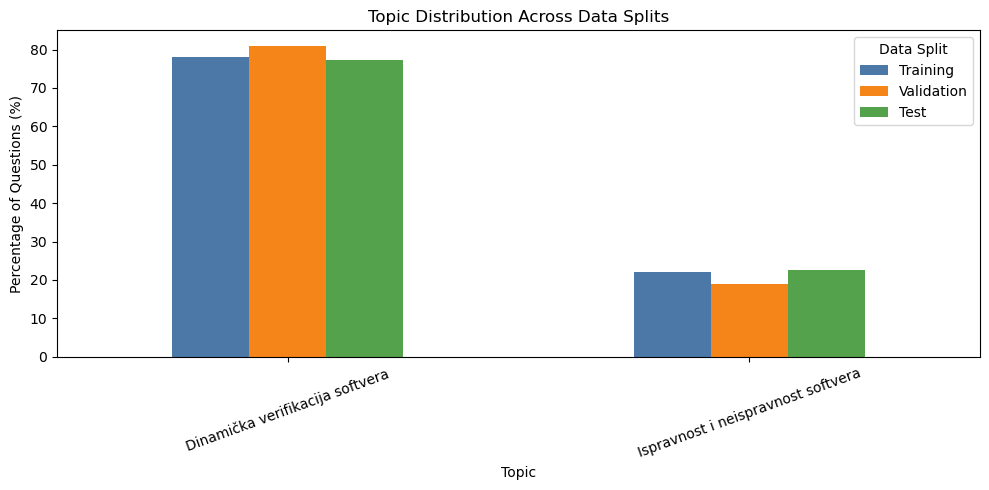

In [26]:
topic_percentages = (
    topic_distribution
    .div(
        topic_distribution.sum(axis=0),
        axis=1
    )
    * 100
)

topic_percentages = topic_percentages.reindex(
    columns=[
        "Training",
        "Validation",
        "Test"
    ]
)

ax = topic_percentages.plot(
    kind="bar",
    figsize=(10, 5),
    color=[
        "#4C78A8",
        "#F58518",
        "#54A24B"
    ]
)

ax.set_title("Topic Distribution Across Data Splits")
ax.set_xlabel("Topic")
ax.set_ylabel("Percentage of Questions (%)")
ax.tick_params(
    axis="x",
    rotation=20
)

ax.legend(
    title="Data Split"
)

plt.tight_layout()
plt.show()

## **Data Analysis**

The dataset contains 356 text chunks and 143 question-answer pairs. After preprocessing, no empty chunks were found, and all 143 question-answer pairs were retained for further processing.

The question-answer dataset contains 12 attributes, including the original and preprocessed versions of questions and answers, topic and subtopic labels, source information, source pages, and the assigned data split.

No missing values were detected in the important attributes. There are no empty questions, empty answers, or examples without corresponding source pages.

The dataset was divided into training, validation, and test sets using an approximately 70:15:15 ratio:

- Training set: 100 examples (69.93%)
- Validation set: 21 examples (14.69%)
- Test set: 22 examples (15.38%)

The three subsets do not overlap, and every valid question-answer pair belongs to exactly one subset.

The dataset is imbalanced with respect to the main topic. Approximately 78% of the examples belong to *Dynamic Software Verification*, while approximately 22% belong to *Software Correctness and Incorrectness*.

Stratified splitting preserved approximately the same topic proportions in the training, validation, and test sets. Therefore, all three subsets remain imbalanced, but their topic distributions are mutually consistent.

In [27]:
# Čuvanje

In [28]:
PROCESSED_CHUNKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "chunks_preprocessed.jsonl"
)

SPLITS_DIR = (
    PROJECT_ROOT
    / "data"
    / "splits"
)

SPLITS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [29]:
def save_jsonl(records: list[dict], path: Path) -> None:
    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with path.open("w", encoding="utf-8") as file:
        for record in records:
            file.write(
                json.dumps(
                    record,
                    ensure_ascii=False
                )
                + "\n"
            )

In [30]:
save_jsonl(
    processed_chunks,
    PROCESSED_CHUNKS_PATH
)

TRAIN_PATH = SPLITS_DIR / "train.jsonl"
VALIDATION_PATH = SPLITS_DIR / "validation.jsonl"
TEST_PATH = SPLITS_DIR / "test.jsonl"

save_jsonl(
    train_data,
    TRAIN_PATH
)
save_jsonl(
    validation_data,
    VALIDATION_PATH
)
save_jsonl(
    test_data,
    TEST_PATH
)